In [23]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import geopandas as gpd
import json
from urllib.request import urlopen
import plotly.express as px

In [24]:
# load CSV
df = pd.read_csv("master_dataset.csv")
#print(df.describe())
df.head()

,county_fips,state,county_name,election_year,total_population,median_age,pct_black,pct_asian,pct_two_or_more_races,pct_hispanic,...,population_density,pct_senior_65plus,pct_young_adult_18_24,pct_foreign_born,dem_votes,rep_votes,total_votes,dem_pct,rep_pct,dem_margin
0,26001,MI,Alcona County,2016,10461,57.4,0.248542,0.411051,1.309626,1.386101,...,15.505703,17.321480,2.619252,0.630915,1732.0,4201.0,6198.0,27.944498,67.779929,-39.835431
1,26003,MI,Alger County,2016,9396,49.0,7.322265,0.276713,4.129417,1.351639,...,10.268471,11.430396,5.119200,0.521499,1663.0,2585.0,4518.0,36.808322,57.215582,-20.407260
2,26005,MI,Allegan County,2016,113666,40.0,1.429627,0.653670,2.075379,7.081273,...,137.734731,6.984498,4.017032,1.454261,18050.0,34183.0,55786.0,32.355788,61.275230,-28.919442
3,26007,MI,Alpena County,2016,28929,47.3,0.594559,0.400982,1.541706,1.296277,...,50.584107,9.692696,3.840437,0.515054,4877.0,9090.0,14698.0,33.181385,61.845149,-28.663764
4,26009,MI,Antrim County,2016,23215,50.0,0.340297,0.267069,1.791945,1.955632,...,48.803920,12.155934,3.372819,0.960586,4448.0,8469.0,13582.0,32.749227,62.354587,-29.605360


/tmp/ipykernel_575/394391198.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


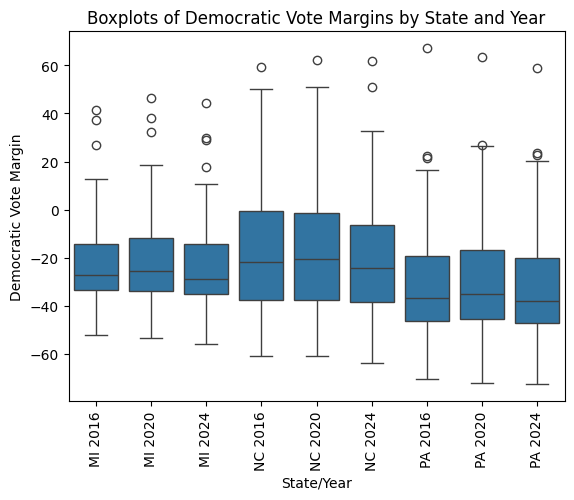

In [25]:
# Create boxplots of dem_margin grouped by state and year
# First step, create new state/year column to group by
df["state_year"] = df.apply(lambda row: f"{row["state"]} {str(row["election_year"])}", axis=1)

# Create the boxplots
ax = sns.boxplot(x="state_year", y="dem_margin", data=df, order=sorted(df["state_year"].unique()))
plt.title("Boxplots of Democratic Vote Margins by State and Year")
plt.xlabel("State/Year")
plt.ylabel("Democratic Vote Margin")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()

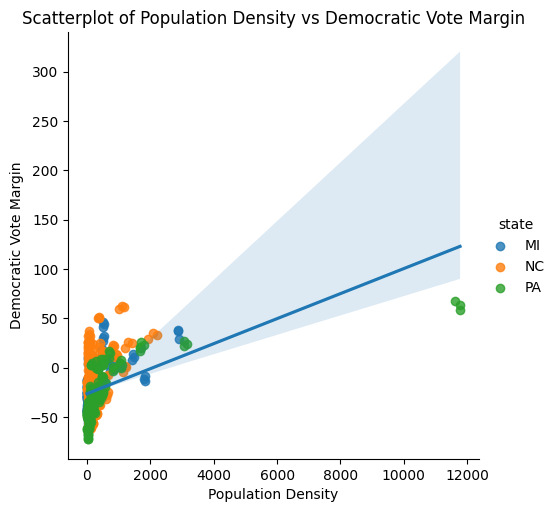

The Pearson Correlation Coefficient is 0.431


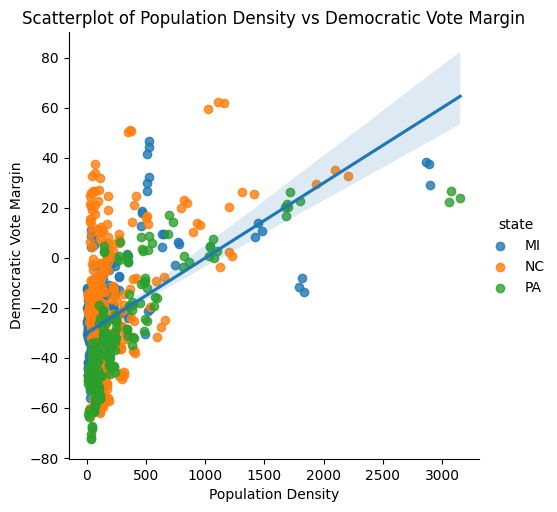

In [26]:
# Create scatterplot of pop. density vs dem margin
g = sns.lmplot(x="population_density", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="population_density", y="dem_margin", data=df, scatter=False, ax=g.axes[0, 0])
plt.title("Scatterplot of Population Density vs Democratic Vote Margin")
plt.xlabel("Population Density")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["population_density"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")
# Remove outliers
dfFiltered = df[df["population_density"] < 11000]
# Create scatterplot with outliers removed
g2 = sns.lmplot(x="population_density", y="dem_margin", hue="state", data=dfFiltered, fit_reg=False)
sns.regplot(x="population_density", y="dem_margin", data=dfFiltered, scatter=False, ax=g2.axes[0, 0])
plt.title("Scatterplot of Population Density vs Democratic Vote Margin")
plt.xlabel("Population Density")
plt.ylabel("Democratic Vote Margin")
plt.show()

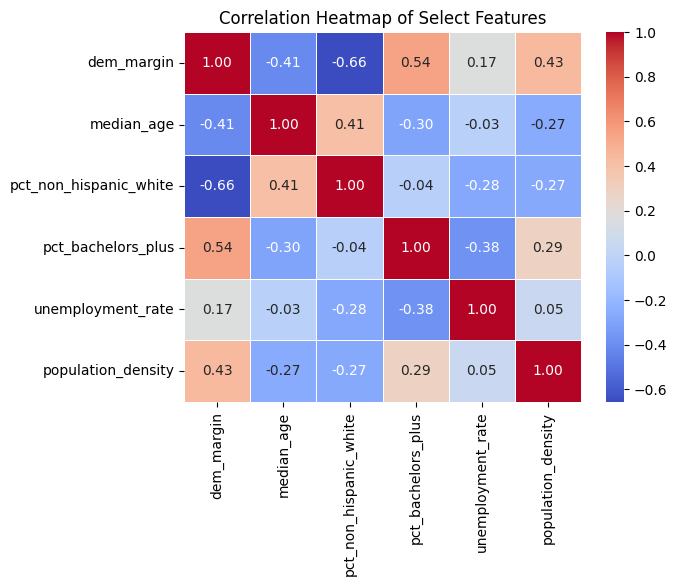

In [27]:
# create the correlation matrix
dfReduced = df[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
corrMatrix = dfReduced.corr()
# create heat map
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features")
plt.show()

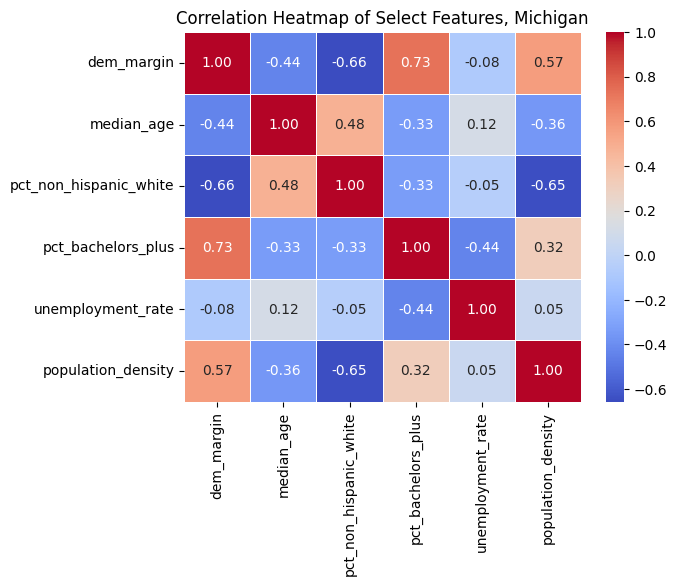

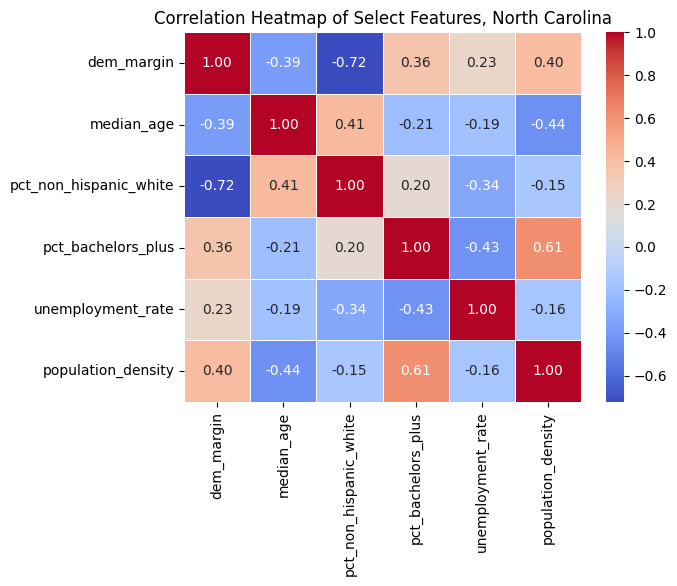

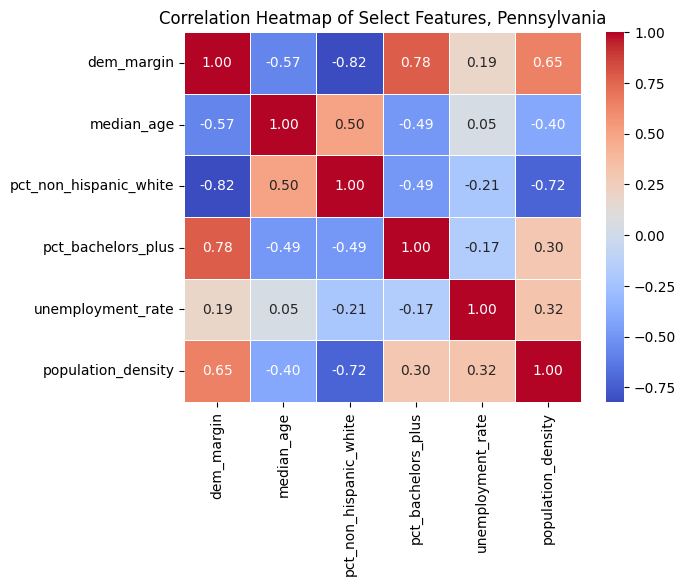

In [28]:
# create the correlation matrixes
dfMi = df[df["state"] == "MI"]
dfNc = df[df["state"] == "NC"]
dfPa = df[df["state"] == "PA"]
dfMiReduced = dfMi[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
dfNcReduced = dfNc[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
dfPaReduced = dfPa[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
corrMatrixMi = dfMiReduced.corr()
corrMatrixNc = dfNcReduced.corr()
corrMatrixPa = dfPaReduced.corr()
# create heat maps
sns.heatmap(corrMatrixMi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features, Michigan")
plt.show()
sns.heatmap(corrMatrixNc, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features, North Carolina")
plt.show()
sns.heatmap(corrMatrixPa, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features, Pennsylvania")
plt.show()

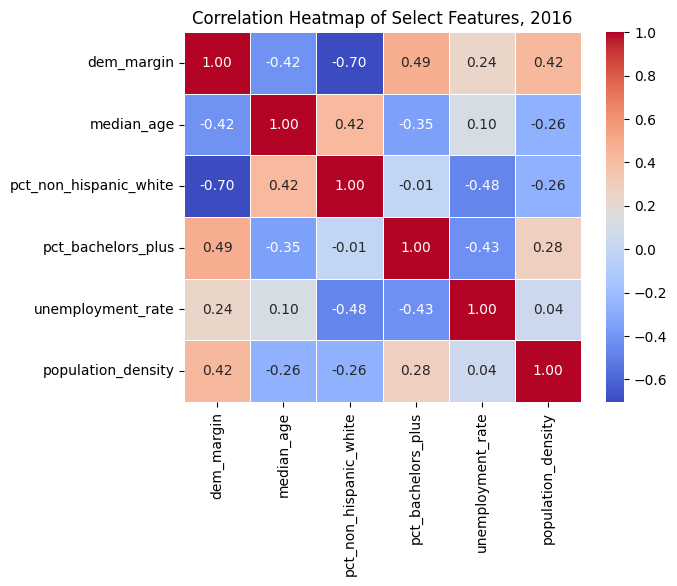

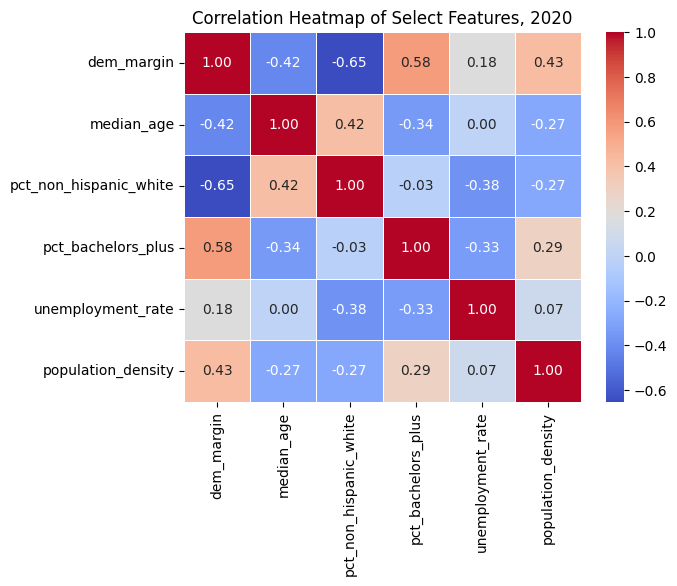

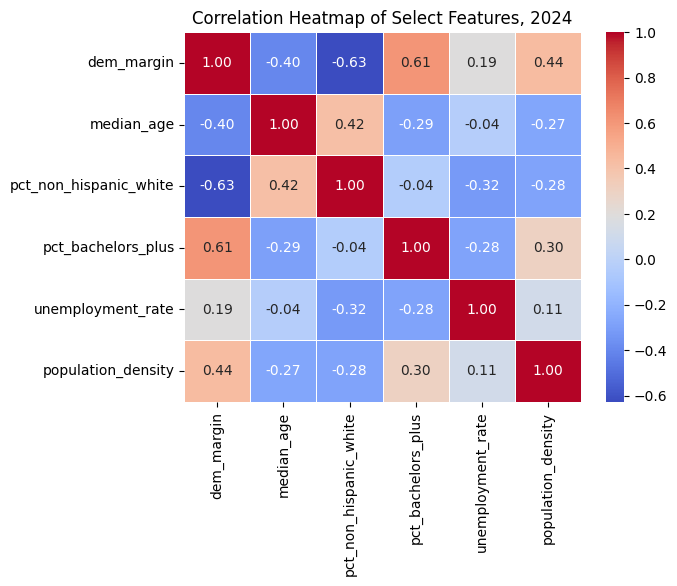

In [29]:
# create the correlation matrixes
df2016 = df[df["election_year"] == 2016]
df2020 = df[df["election_year"] == 2020]
df2024 = df[df["election_year"] == 2024]
df2016Reduced = df2016[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
df2020Reduced = df2020[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
df2024Reduced = df2024[["dem_margin", "median_age", "pct_non_hispanic_white", "pct_bachelors_plus", "unemployment_rate", "population_density"]]
corrMatrix2016 = df2016Reduced.corr()
corrMatrix2020 = df2020Reduced.corr()
corrMatrix2024 = df2024Reduced.corr()
# create heat maps
sns.heatmap(corrMatrix2016, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features, 2016")
plt.show()
sns.heatmap(corrMatrix2020, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features, 2020")
plt.show()
sns.heatmap(corrMatrix2024, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Select Features, 2024")
plt.show()

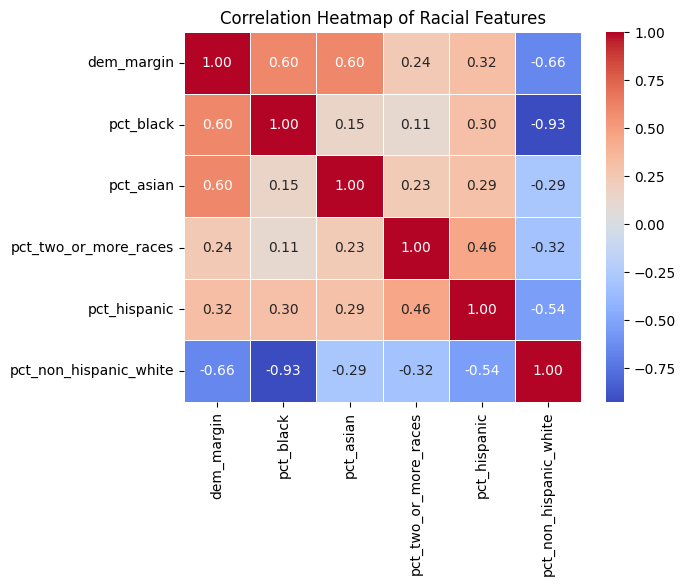

In [30]:
# create the correlation matrix
dfReduced2 = df[["dem_margin", "pct_black", "pct_asian", "pct_two_or_more_races", "pct_hispanic", "pct_non_hispanic_white"]]
corrMatrix = dfReduced2.corr()
# create heat map
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Racial Features")
plt.show()

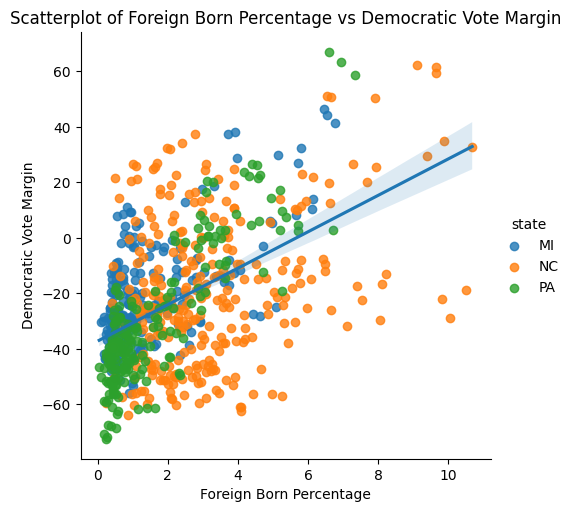

The Pearson Correlation Coefficient is 0.518


In [31]:
# Create scatterplot of pct. foreign born vs dem margin
g = sns.lmplot(x="pct_foreign_born", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="pct_foreign_born", y="dem_margin", data=df, scatter=False, ax=g.axes[0, 0])
plt.title("Scatterplot of Foreign Born Percentage vs Democratic Vote Margin")
plt.xlabel("Foreign Born Percentage")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["pct_foreign_born"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")

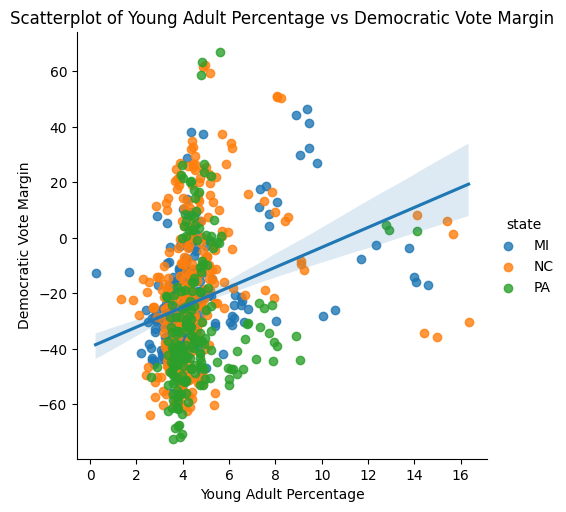

The Pearson Correlation Coefficient is 0.273


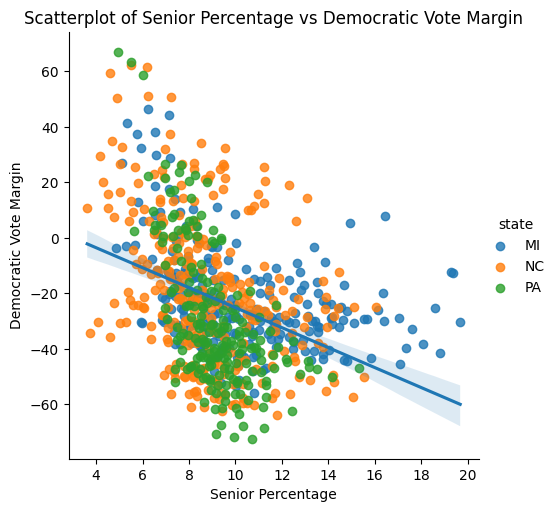

The Pearson Correlation Coefficient is -0.378


In [32]:
# Create scatterplot of pct. young adults vs dem margin
g = sns.lmplot(x="pct_young_adult_18_24", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="pct_young_adult_18_24", y="dem_margin", data=df, scatter=False, ax=g.axes[0, 0])
plt.title("Scatterplot of Young Adult Percentage vs Democratic Vote Margin")
plt.xlabel("Young Adult Percentage")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["pct_young_adult_18_24"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")
# Create scatterplot of pct. seniors vs dem margin
g2 = sns.lmplot(x="pct_senior_65plus", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="pct_senior_65plus", y="dem_margin", data=df, scatter=False, ax=g2.axes[0, 0])
plt.title("Scatterplot of Senior Percentage vs Democratic Vote Margin")
plt.xlabel("Senior Percentage")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["pct_senior_65plus"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")

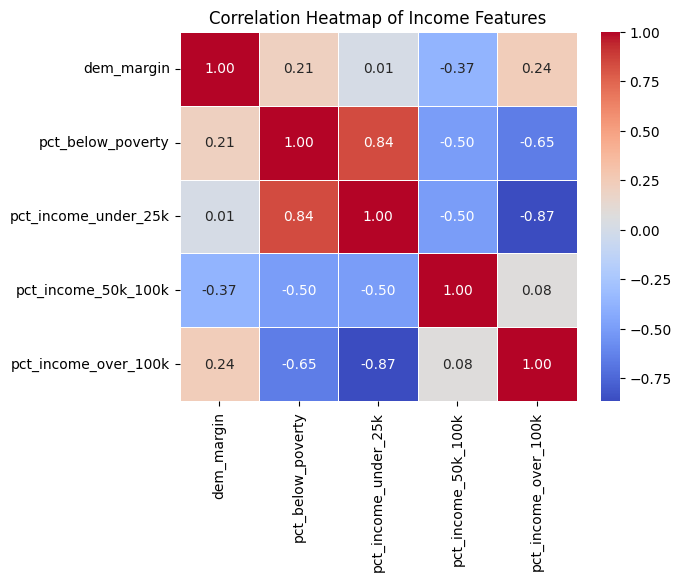

In [33]:
# create the correlation matrix
dfReduced3 = df[["dem_margin", "pct_below_poverty", "pct_income_under_25k", "pct_income_50k_100k", "pct_income_over_100k"]]
corrMatrix = dfReduced3.corr()
# create heat map
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Income Features")
plt.show()

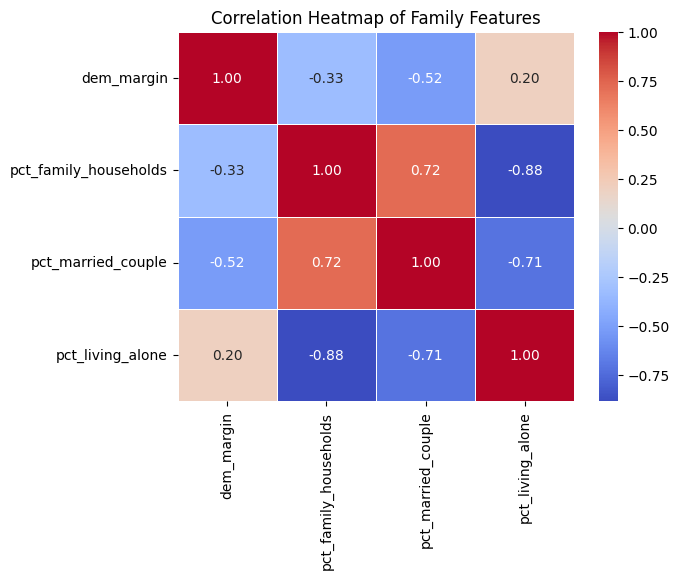

In [34]:
# create the correlation matrix
dfReduced4 = df[["dem_margin", "pct_family_households", "pct_married_couple", "pct_living_alone"]]
corrMatrix = dfReduced4.corr()
# create heat map
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Family Features")
plt.show()

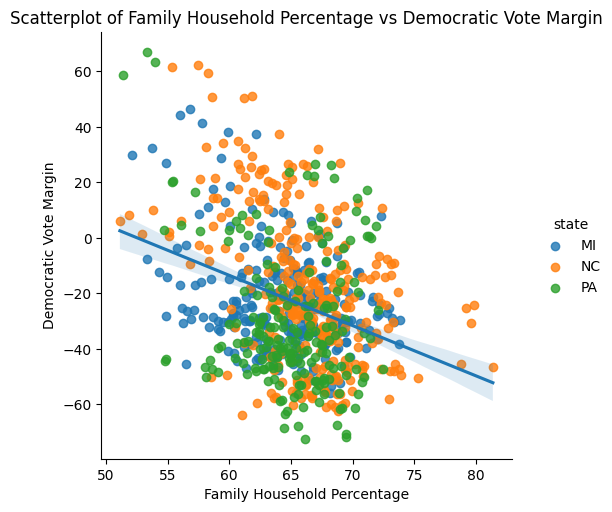

The Pearson Correlation Coefficient is -0.326


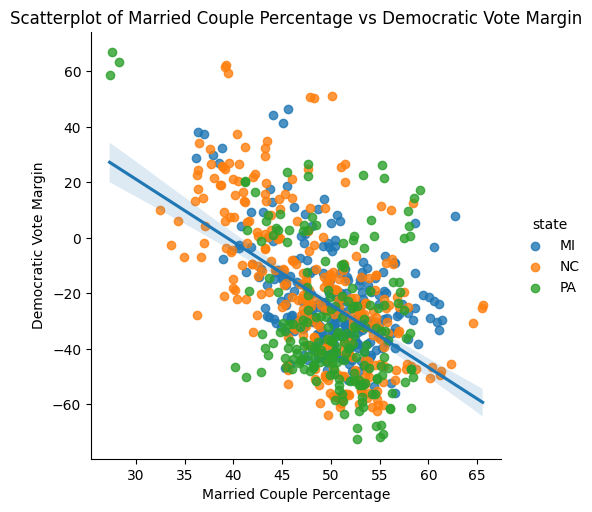

The Pearson Correlation Coefficient is -0.516


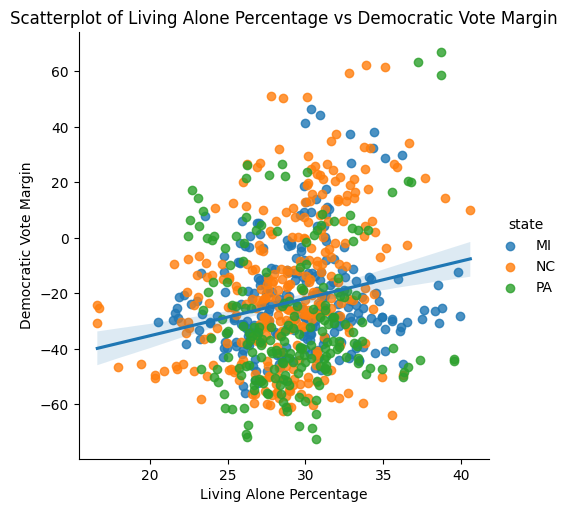

The Pearson Correlation Coefficient is 0.203


In [35]:
# Create scatterplot of pct. families vs dem margin
g = sns.lmplot(x="pct_family_households", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="pct_family_households", y="dem_margin", data=df, scatter=False, ax=g.axes[0, 0])
plt.title("Scatterplot of Family Household Percentage vs Democratic Vote Margin")
plt.xlabel("Family Household Percentage")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["pct_family_households"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")
# Create scatterplot of pct. married couples vs dem margin
g2 = sns.lmplot(x="pct_married_couple", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="pct_married_couple", y="dem_margin", data=df, scatter=False, ax=g2.axes[0, 0])
plt.title("Scatterplot of Married Couple Percentage vs Democratic Vote Margin")
plt.xlabel("Married Couple Percentage")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["pct_married_couple"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")
# Create scatterplot of pct. living alone vs dem margin
g3 = sns.lmplot(x="pct_living_alone", y="dem_margin", hue="state", data=df, fit_reg=False)
sns.regplot(x="pct_living_alone", y="dem_margin", data=df, scatter=False, ax=g3.axes[0, 0])
plt.title("Scatterplot of Living Alone Percentage vs Democratic Vote Margin")
plt.xlabel("Living Alone Percentage")
plt.ylabel("Democratic Vote Margin")
plt.show()
# Calculate and print the Pearson Correlation Coefficient
r, p = stats.pearsonr(df["pct_living_alone"], df["dem_margin"])
print(f"The Pearson Correlation Coefficient is {r:.3f}")

In [36]:
dfVol = pd.read_csv("county_volatility_dimTable.csv")
dfVol.head()

,county_fips,county_name,dem_margin_2016,dem_margin_2020,dem_margin_2024,d_16_20,d_20_24,swing_dir_score,swing_mag_16_20,swing_mag_20_24,z_swing_mag_16_20,z_swing_mag_20_24,vol_z_abs_sum,vol_z_euc
0,26001,Alcona County,-0.696285,-0.633409,-0.771109,0.062876,-0.137700,-86.579965,0.062876,0.137700,-0.591031,0.370535,-0.220496,0.697577
1,26003,Alger County,0.102894,0.171466,0.127939,0.068573,-0.043527,-29.847678,0.068573,0.043527,-0.532631,-0.780649,-1.313280,0.945044
2,26005,Allegan County,-0.247255,-0.096421,-0.177021,0.150834,-0.080601,-121.573636,0.150834,0.080601,0.310683,-0.327456,-0.016772,0.451388
3,26007,Alpena County,-0.236738,-0.193599,-0.235568,0.043138,-0.041969,-18.104691,0.043138,0.041969,-0.793371,-0.799698,-1.593069,1.126479
4,26009,Antrim County,-0.275470,-0.034639,-0.034924,0.240831,-0.000285,-0.685601,0.240831,0.000285,1.233295,-1.309253,-0.075958,1.798655


In [37]:
# load CSV
dfEnt = pd.read_csv("master_dataset_scaled.csv")
#print(df.describe())
dfEnt.head()

,county_fips,state,county_name,election_year,median_age,pct_black,pct_asian,pct_two_or_more_races,pct_hispanic,pct_non_hispanic_white,...,total_votes,dem_pct,rep_pct,dem_margin,log_total_population,log_population_density,log_median_household_income,log_median_home_value,log_median_gross_rent,race_entropy_norm
0,26001,MI,Alcona County,2016,2.614468,-0.752045,-0.525598,-0.999627,-0.950926,1.024264,...,6198.0,-0.780845,0.609162,-0.696285,-1.431676,-1.563760,-1.396449,-1.195395,-1.300373,0.133851
1,26003,MI,Alger County,2016,1.022653,-0.231963,-0.609549,0.135856,-0.958692,0.328591,...,4518.0,-0.051602,-0.256304,0.102894,-1.519842,-1.876941,-1.075048,-0.690145,-1.168218,0.396906
2,26005,MI,Allegan County,2016,-0.682863,-0.665208,-0.373979,-0.691271,0.332456,0.593740,...,55786.0,-0.417920,0.076276,-0.247255,0.527392,0.182957,0.149829,-0.174538,-0.215427,0.298732
3,26007,MI,Alpena County,2016,0.700500,-0.726605,-0.531890,-0.906172,-0.971167,1.023276,...,14698.0,-0.349997,0.122965,-0.236738,-0.596376,-0.628800,-1.220534,-1.326160,-1.467455,0.139122
4,26009,MI,Antrim County,2016,1.212154,-0.745299,-0.615576,-0.805405,-0.822585,0.966915,...,13582.0,-0.385551,0.164700,-0.275470,-0.777078,-0.657615,-0.385434,-0.165597,-0.567235,0.155527


In [38]:
# Merge data with map JSON file
dfVol["county_fips"] = dfVol["county_fips"].astype(str)
geoDataCounties = gpd.read_file("https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/US-counties.geojson")
geoDataCounties["id"] = geoDataCounties["id"].astype(str)
geoDataCounties.head()
mergedData = geoDataCounties.merge(dfVol, left_on="id", right_on="county_fips", how="inner")
mergedData.head()

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry,county_fips,county_name,...,dem_margin_2024,d_16_20,d_20_24,swing_dir_score,swing_mag_16_20,swing_mag_20_24,z_swing_mag_16_20,z_swing_mag_20_24,vol_z_abs_sum,vol_z_euc
0,26009,0500000US26009,26,009,Antrim,County,475.703,"POLYGON ((-85.33284 44.81237, -85.44225 44.859...",26009,Antrim County,...,-0.034924,0.240831,-0.000285,-0.685601,0.240831,0.000285,1.233295,-1.309253,-0.075958,1.798655
1,26015,0500000US26015,26,015,Barry,County,553.092,"POLYGON ((-85.07424 42.77078, -85.07161 42.421...",26015,Barry County,...,-0.469716,0.030782,-0.074616,-22.968371,0.030782,0.074616,-0.920043,-0.400612,-1.320655,1.003479
2,26023,0500000US26023,26,023,Branch,County,506.369,"POLYGON ((-85.25985 42.07185, -84.82649 42.072...",26023,Branch County,...,-0.800855,-0.017254,-0.159775,27.566966,0.017254,0.159775,-1.058731,0.640389,-0.418342,1.237340
3,26035,0500000US26035,26,035,Clare,County,564.315,"POLYGON ((-84.6081 44.16048, -84.608 44.15859,...",26035,Clare County,...,-0.604024,-0.122971,-0.115829,142.435692,0.122971,0.115829,0.025039,0.103178,0.128217,0.106173
4,26037,0500000US26037,26,037,Clinton,County,566.408,"POLYGON ((-84.3678 43.11794, -84.36571 42.9551...",26037,Clinton County,...,0.588405,0.251831,-0.085299,-214.810013,0.251831,0.085299,1.346053,-0.270018,1.076035,1.372869


In [39]:
# Merge 2024 data with map JSON file
dfEnt["county_fips"] = dfEnt["county_fips"].astype(str)
dfEnt2024 = dfEnt.loc[dfEnt["election_year"] == 2024]
geoDataCounties = gpd.read_file("https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/US-counties.geojson")
geoDataCounties["id"] = geoDataCounties["id"].astype(str)
geoDataCounties.head()
mergedDataEnt = geoDataCounties.merge(dfEnt2024, left_on="id", right_on="county_fips", how="inner")
mergedDataEnt.head()

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry,county_fips,state,...,total_votes,dem_pct,rep_pct,dem_margin,log_total_population,log_population_density,log_median_household_income,log_median_home_value,log_median_gross_rent,race_entropy_norm
0,26009,0500000US26009,26,009,Antrim,County,475.703,"POLYGON ((-85.33284 44.81237, -85.44225 44.859...",26009,MI,...,16883.0,0.004755,0.074288,-0.034924,-0.745435,-0.626622,1.211058,1.299955,0.558164,0.217732
1,26015,0500000US26015,26,015,Barry,County,553.092,"POLYGON ((-85.07424 42.77078, -85.07161 42.421...",26015,MI,...,38625.0,-0.440589,0.496750,-0.469716,0.048079,0.033575,1.509959,1.385706,0.888133,0.229780
2,26023,0500000US26023,26,023,Branch,County,506.369,"POLYGON ((-85.25985 42.07185, -84.82649 42.072...",26023,MI,...,21089.0,-0.773907,0.824328,-0.800855,-0.228095,-0.167995,0.707075,0.127759,0.828687,0.338137
3,26035,0500000US26035,26,035,Clare,County,564.315,"POLYGON ((-84.6081 44.16048, -84.608 44.15859,...",26035,MI,...,17288.0,-0.570523,0.634848,-0.604024,-0.533841,-0.556802,-0.338734,-0.375605,-0.169027,0.217853
4,26037,0500000US26037,26,037,Clinton,County,566.408,"POLYGON ((-84.3678 43.11794, -84.36571 42.9551...",26037,MI,...,49986.0,0.615150,-0.559304,0.588405,0.235100,0.198266,2.040968,1.340192,1.402113,0.344845


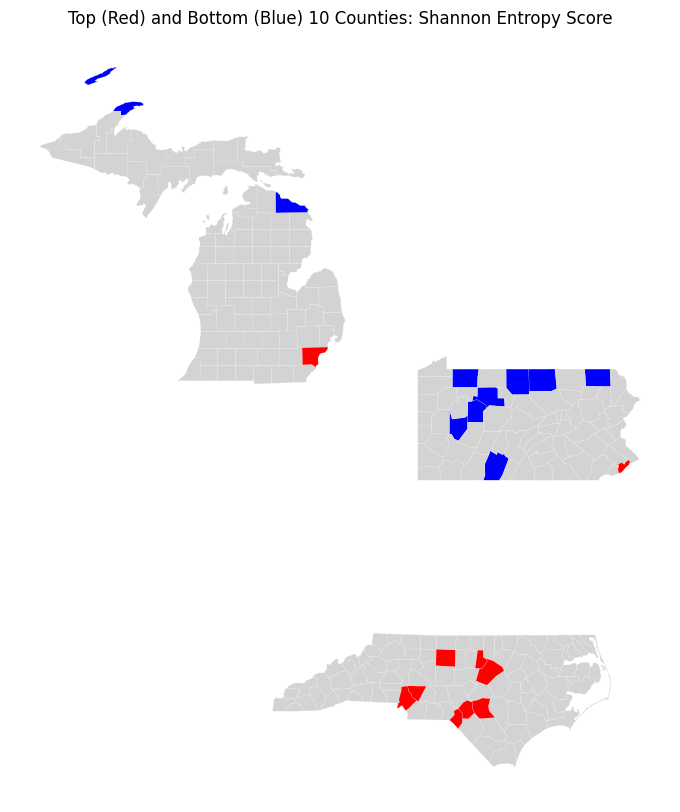

,County,State,Value
201,Jefferson County,PA,0.149714
177,Bedford County,PA,0.160118
165,Tioga County,PA,0.169564
56,Armstrong County,PA,0.170512
53,Potter County,PA,0.173687
218,Presque Isle County,MI,0.175679
48,Elk County,PA,0.177591
55,Warren County,PA,0.187603
145,Susquehanna County,PA,0.188039
10,Keweenaw County,MI,0.188761


In [40]:
# Find top and bottom 10 Shannon Entropy county scores
top10 = mergedDataEnt.nlargest(10, "race_entropy_norm")
bottom10 = mergedDataEnt.nsmallest(10, "race_entropy_norm")
mergedDataEnt["coloring"] = "Others"
mergedDataEnt.loc[mergedDataEnt["county_fips"].isin(top10["county_fips"]), "coloring"] = "Top 10"
mergedDataEnt.loc[mergedDataEnt["county_fips"].isin(bottom10["county_fips"]), "coloring"] = "Bottom 10"

fig, ax = plt.subplots(figsize=(10, 10))
colors = {"Top 10": "red", "Bottom 10": "blue", "Others": "lightgray"}
# Plot counties (choropleth)
for ctype, data in mergedDataEnt.groupby("coloring"):
    color = colors[ctype]
    data.plot(ax=ax, color=color, label=ctype,
              edgecolor='white', linewidth=0.1,
              legend=True)

plt.title("Top (Red) and Bottom (Blue) 10 Counties: Shannon Entropy Score")
plt.axis("off")
plt.show()

# Create df of extremes
dfExtremes = pd.concat([top10, bottom10], axis=0)
stateCodes = {"26": "MI", "37": "NC", "42": "PA"}
dfExtremes["state_str"] = dfExtremes["STATE"].map(stateCodes)
dfRenamed = dfExtremes.rename(columns={"county_name": "County", "state_str": "State", "race_entropy_norm": "Value"})
dfRenamed[["County", "State", "Value"]].sort_values(by="Value")


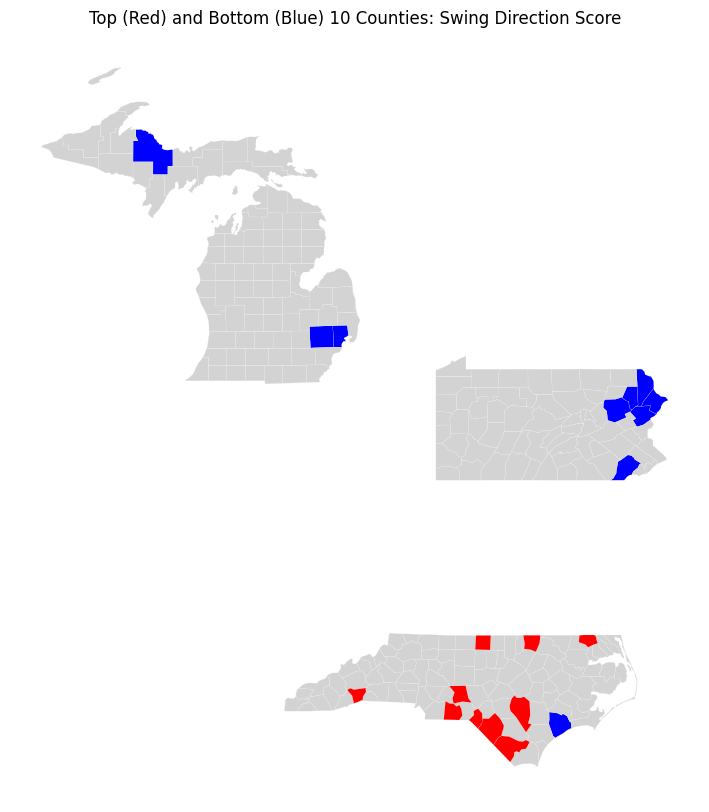

,County,State,Value
140,Monroe County,PA,-677.087181
243,Pike County,PA,-597.005215
50,Lackawanna County,PA,-461.664883
126,Luzerne County,PA,-409.311324
189,Onslow County,NC,-393.875548
87,Oakland County,MI,-347.423282
116,Chester County,PA,-340.773543
83,Macomb County,MI,-328.069601
14,Marquette County,MI,-283.609718
209,Wayne County,PA,-282.682716


In [41]:
# Find top and bottom 10 swing direction county scores
top10 = mergedData.nlargest(10, "swing_dir_score")
bottom10 = mergedData.nsmallest(10, "swing_dir_score")
mergedData["coloring"] = "Others"
mergedData.loc[mergedData["county_fips"].isin(top10["county_fips"]), "coloring"] = "Top 10"
mergedData.loc[mergedData["county_fips"].isin(bottom10["county_fips"]), "coloring"] = "Bottom 10"

fig, ax = plt.subplots(figsize=(10, 10))
colors = {"Top 10": "red", "Bottom 10": "blue", "Others": "lightgray"}
# Plot counties
for ctype, data in mergedData.groupby("coloring"):
    color = colors[ctype]
    data.plot(ax=ax, color=color, label=ctype,
              edgecolor='white', linewidth=0.1,
              legend=True)

plt.title("Top (Red) and Bottom (Blue) 10 Counties: Swing Direction Score")
plt.axis("off")
plt.show()

# Create df of extremes
dfExtremes = pd.concat([top10, bottom10], axis=0)
stateCodes = {"26": "MI", "37": "NC", "42": "PA"}
dfExtremes["state_str"] = dfExtremes["STATE"].map(stateCodes)
dfRenamed = dfExtremes.rename(columns={"county_name": "County", "state_str": "State", "swing_dir_score": "Value"})
dfRenamed[["County", "State", "Value"]].sort_values(by="Value")